Financial markets generate massive volumes of data in real time, making it challenging
to monitor trends and detect unusual activities effectively. Cryptocurrency markets, in
particular, operate 24/7 and produce high-frequency trading data, making them an ideal
use case for big data analytics.
This project focuses on analyzing real-time cryptocurrency market data using big data
technologies. By leveraging streaming data from the Binance API (or Historical Data),
the project will simulate a real-world financial analytics system capable of processing
large volumes of data continuously.

##Significance of the Project
The objective of this project is to identify meaningful insights from cryptocurrency
trading data, including market trends, price volatility, and unusual trading patterns.
Detecting anomalies such as sudden price spikes or abnormal trading volumes can help
in understanding market behavior and potential risks.
This project demonstrates how big data tools can be applied in financial systems for
real-time analytics, which is highly relevant in domains such as algorithmic trading,
fraud detection, and risk management. The results can provide insights into how
financial institutions monitor and analyze large-scale market data for decision-making.

In [ ]:
#Installation
!sudo apt-get update -qq
!sudo apt-get install python3.10 python3.10-distutils -y
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'python3-distutils' instead of 'python3.10-distutils'
python3-distutils is already the newest version (3.10.8-1~22.04).
python3-distutils set to manually installed.
python3.10 is already the newest version (3.10.12-1~22.04.15).
python3.10 set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


In [ ]:
!apt-get install openjdk-11-jdk-headless -qq
!pip install pyspark==3.5.0
!pip install findspark

Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid (rmid) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/pack200 to provide /usr/bin/pack200 (pack200) in auto mode
update-alternatives: using /usr/lib/jvm/jav

In [ ]:
!python3 --version
!java -version

Python 3.12.13
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [ ]:
#Setting Java and Python Home ( Environment Variable-Path configuration)
import os, sys

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

In [ ]:
#Accessing Googl drive from Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
data = pd.read_csv("/content/drive/Shareddrives/BIg Data Final/BIGDATAFINAL/BINANCEHIS.csv")

In [ ]:
data.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183,2017-08-17 04:00:59.999,7564.906851,3.0,0.075183,320.390851,0.0
1,2017-08-17 04:01:00,4261.48,4261.48,4261.48,4261.48,0.000000,2017-08-17 04:01:59.999,0.000000,0.0,0.000000,0.000000,0.0
2,2017-08-17 04:02:00,4280.56,4280.56,4280.56,4280.56,0.261074,2017-08-17 04:02:59.999,1117.542921,2.0,0.261074,1117.542921,0.0
3,2017-08-17 04:03:00,4261.48,4261.48,4261.48,4261.48,0.012008,2017-08-17 04:03:59.999,51.171852,3.0,0.012008,51.171852,0.0
4,2017-08-17 04:04:00,4261.48,4261.48,4261.48,4261.48,0.140796,2017-08-17 04:04:59.999,599.999338,1.0,0.140796,599.999338,0.0


In [ ]:
pip install websocket-client

In [ ]:
!pip install pyarrow

In [ ]:
import pandas as pd

# 1. Load the data
df = pd.read_csv("/content/drive/Shareddrives/BIg Data Final/BIGDATAFINAL/BINANCEHIS.csv")

# 2. Convert to datetime
df['timestamp'] = pd.to_datetime(df['Open time'])

# 3. Filter for 2023 onwards
df_modern = df[df['timestamp'] >= '2023-01-01'].copy()

# 4. allow_truncated_timestamps=True)
# We also set coerce_timestamps for Spark compatibility
df_modern.to_parquet(
    "/content/drive/Shareddrives/BIg Data Final/BIGDATAFINAL/BTC_MODERN_23_25.parquet",
    engine='pyarrow',
    index=False,
    coerce_timestamps='us',
    allow_truncated_timestamps=True
)

print("File saved successfully with Spark-compatible")

File saved successfully with Spark-compatible


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import col, lag, avg, desc , round


spark = SparkSession.builder \
    .appName("BTCrypto_Analytics") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print("Spark Session Created Successfully!")

Spark Session Created Successfully!


In [ ]:
# Spark is smart enough to read a single parquet file OR a folder of parquet files
df_spark = spark.read.parquet("/content/drive/Shareddrives/BIg Data Final/BIGDATAFINAL/BTC_MODERN_23_25.parquet")
df_spark.show(5)

+-------------------+--------+--------+--------+--------+---------+--------------------+------------------+----------------+---------------------------+----------------------------+------+-------------------+
|          Open time|    Open|    High|     Low|   Close|   Volume|          Close time|Quote asset volume|Number of trades|Taker buy base asset volume|Taker buy quote asset volume|Ignore|          timestamp|
+-------------------+--------+--------+--------+--------+---------+--------------------+------------------+----------------+---------------------------+----------------------------+------+-------------------+
|2023-01-01 00:00:00|16541.77|16544.76|16538.45|16543.67| 83.08143|2023-01-01 00:00:...|   1374268.8488616|          2687.0|                   40.18369|              664706.0110636|   0.0|2023-01-01 00:00:00|
|2023-01-01 00:01:00|16543.04|16544.41|16538.48|16539.31|   80.453|2023-01-01 00:01:...|   1330772.8885466|          2890.0|                   33.28428|            

:## Text explaining what we are doing here


In [ ]:
from pyspark.sql import functions as F

# Grouping by month and summing volume
monthly_stats = df_spark.withColumn("Month", F.trunc("timestamp", "MM")) \
    .groupBy("Month") \
    .agg(F.sum("Volume").alias("Total_Volume"),
         F.avg("Close").alias("Avg_Price")) \
    .orderBy("Month")

monthly_stats.show()

+----------+------------------+------------------+
|     Month|      Total_Volume|         Avg_Price|
+----------+------------------+------------------+
|2023-01-01| 7977028.878010007|20120.714262544974|
|2023-02-01| 8642691.271650007|23296.022164186463|
|2023-03-01| 9516189.358459914|25001.758309919307|
|2023-04-01|1626745.5584999924|28833.283433101427|
|2023-05-01|1302000.4922099982|27480.922186828022|
|2023-06-01|1387207.4827500132| 27686.36519930567|
|2023-07-01|  925773.817310001|30083.964516576998|
|2023-08-01|1025866.5502299964| 27910.90541420223|
|2023-09-01| 809329.0489299987|26299.142942129703|
|2023-10-01|1141403.6798999875|29618.219976702596|
|2023-11-01|1055690.5963799937| 36484.31814282377|
|2023-12-01|1195409.9759999926| 42423.89568548241|
|2024-01-01|1403408.8497800143| 42924.80114874341|
|2024-02-01|1206112.6954499937| 49496.30433165466|
|2024-03-01|1706807.3813420048| 67513.86063978364|
|2024-04-01|1201500.9585200022| 65953.14126273093|
|2024-05-01| 945031.0407199977|

In [ ]:
df_spark.printSchema()

root
 |-- Open time: string (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Close time: string (nullable = true)
 |-- Quote asset volume: double (nullable = true)
 |-- Number of trades: double (nullable = true)
 |-- Taker buy base asset volume: double (nullable = true)
 |-- Taker buy quote asset volume: double (nullable = true)
 |-- Ignore: double (nullable = true)
 |-- timestamp: timestamp_ntz (nullable = true)



In [ ]:
from pyspark.sql.functions import hour, dayofweek, avg, col, stddev

# 1. Extract Hour and Day of Week
# dayofweek: 1 = Sunday, 7 = Saturday
df_time = df_spark.withColumn("hour", hour(col("timestamp"))) \
            .withColumn("day_of_week", dayofweek(col("timestamp")))

# 2. Calculate Average Volume by Hour
hourly_volume = df_time.groupBy("hour").agg(avg("Volume").alias("avg_volume")) \
                       .orderBy("hour")

print("Average Volume by Hour of Day:")
hourly_volume.show(24)

# 3. Calculate Average Volume by Day of Week
daily_volume = df_time.groupBy("day_of_week").agg(avg("Volume").alias("avg_volume")) \
                      .orderBy("day_of_week")

print("Average Volume by Day of Week:")
daily_volume.show()

Average Volume by Hour of Day:
+----+------------------+
|hour|        avg_volume|
+----+------------------+
|   0| 36.72027332023016|
|   1| 36.14010913098534|
|   2|32.000299969687845|
|   3|27.640851403119992|
|   4|25.231813293448155|
|   5| 26.03414302494228|
|   6|27.708799735320408|
|   7|31.810418823497432|
|   8|33.461751503202045|
|   9| 32.96112623083728|
|  10| 32.34963705699522|
|  11| 32.12941904988277|
|  12| 40.57070564797781|
|  13| 49.76644705473852|
|  14| 62.52774390693615|
|  15| 62.75283518573247|
|  16| 53.52813888938187|
|  17| 46.25317735207092|
|  18| 43.53110797905965|
|  19| 44.09409455351754|
|  20| 41.81453347863276|
|  21|32.977581531772046|
|  22|  29.9802593279911|
|  23| 30.15779045465168|
+----+------------------+

Average Volume by Day of Week:
+-----------+------------------+
|day_of_week|        avg_volume|
+-----------+------------------+
|          1|26.197878154836648|
|          2|43.050142558448485|
|          3| 43.13885348969331|
|          

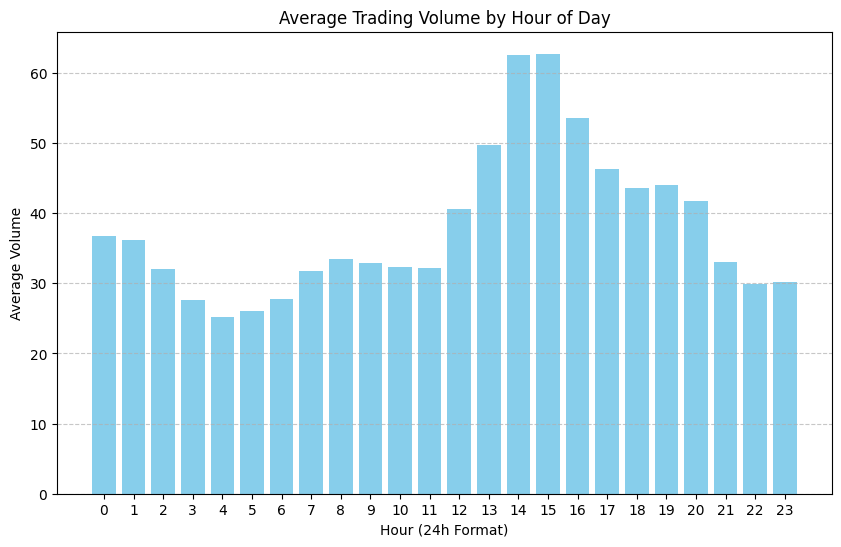

In [ ]:
import matplotlib.pyplot as plt

# Convert the Spark aggregation to Pandas for plotting
hourly_pd = hourly_volume.toPandas()

plt.figure(figsize=(10, 6))
plt.bar(hourly_pd['hour'], hourly_pd['avg_volume'], color='skyblue')
plt.title('Average Trading Volume by Hour of Day')
plt.xlabel('Hour (24h Format)')
plt.ylabel('Average Volume')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from pyspark.sql.functions import minute

# 1. Extract the minute from the timestamp
df_minute = df_spark.withColumn("minute", minute(col("timestamp")))

# 2. Calculate Average Volume by Minute
minute_volume = df_minute.groupBy("minute").agg(avg("Volume").alias("avg_volume")) \
                         .orderBy("minute")

print("Average Volume by Minute (0-59):")
minute_volume.show(60)

Average Volume by Minute (0-59):
+------+------------------+
|minute|        avg_volume|
+------+------------------+
|     0|47.333440637901724|
|     1| 42.89303963777887|
|     2|41.327958670185154|
|     3| 40.21437705536835|
|     4| 38.37002784560072|
|     5|  40.0891994502587|
|     6| 40.12652501688149|
|     7| 39.85911427257047|
|     8| 38.68790761159963|
|     9|37.800959683068974|
|    10| 38.55357151178815|
|    11| 37.94542760469915|
|    12| 37.93153303446126|
|    13|36.426697010966954|
|    14|35.414991343711485|
|    15| 40.29183498246126|
|    16| 39.05372239558853|
|    17| 38.67346673215309|
|    18| 37.55437792273869|
|    19| 36.48023427515813|
|    20|  38.0844399297623|
|    21|38.345738099112545|
|    22| 37.16044477121502|
|    23| 36.72958815591848|
|    24| 35.56772790770539|
|    25| 36.97230699716572|
|    26| 35.93299863739454|
|    27| 35.76444819095537|
|    28| 34.77907162642762|
|    29| 34.54874375761923|
|    30|44.573384845641854|
|    31|41.6983

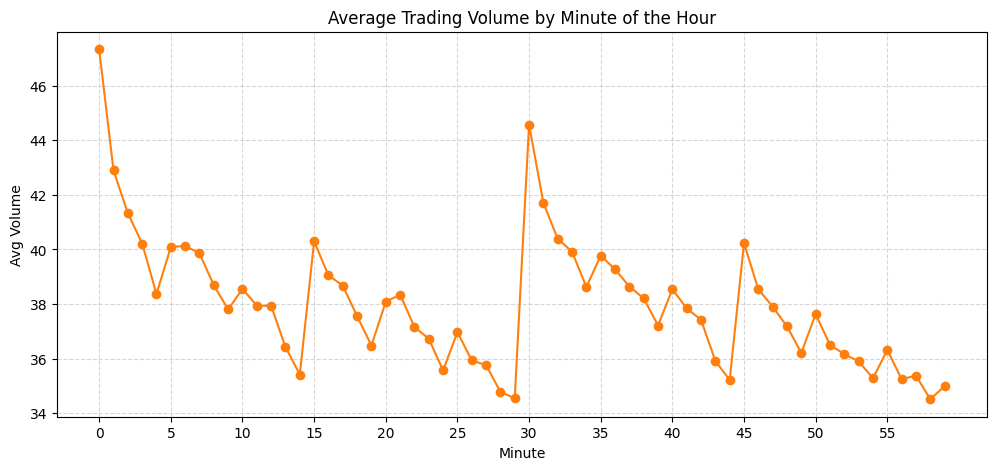

In [ ]:
import matplotlib.pyplot as plt

# Convert to Pandas for plotting
minute_pd = minute_volume.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(minute_pd['minute'], minute_pd['avg_volume'], marker='o', linestyle='-', color='tab:orange')
plt.title('Average Trading Volume by Minute of the Hour')
plt.xlabel('Minute')
plt.ylabel('Avg Volume')
plt.xticks(range(0, 60, 5)) # Show every 5th minute for clarity
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from pyspark.sql.functions import hour, minute, avg, col

# 1. Verification: Check for null timestamps or volumes
null_count = df_spark.filter(col("timestamp").isNull() | col("Volume").isNull()).count()
print(f"Dataset Quality Check: {null_count} null rows found.")

# 2. Add Time Parts
df_analyzed = df_spark.withColumn("hour", hour(col("timestamp"))) \
                .withColumn("minute", minute(col("timestamp")))

# 3. Analyze Volume Spikes by Minute (The "Systemic" Check)
# This will show if volume spikes specifically at :00, :15, :30, or :45
minute_stats = df_analyzed.groupBy("minute").agg(avg("Volume").alias("avg_vol")) \
                          .orderBy(col("avg_vol").desc())

print("Top 5 Minutes with Highest Activity:")
minute_stats.show(5)




Dataset Quality Check: 0 null rows found.
Top 5 Minutes with Highest Activity:
+------+------------------+
|minute|           avg_vol|
+------+------------------+
|     0|47.333440637901724|
|    30|44.573384845641854|
|     1| 42.89303963777887|
|    31|41.698374556271936|
|     2|41.327958670185154|
+------+------------------+
only showing top 5 rows



Kafka Example


> Add blockquote


